In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")
wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [3]:
wego.shape

(350329, 30)

In [4]:
wego.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

How does direction of travel, route, or location affect the on-time performance?

In [6]:
#using Bre's cleaning code so that we're all working with the same data
wego_clean = wego.dropna(subset=['ADHERENCE', 'ACTUAL_DEPARTURE_TIME', 'SCHEDULED_TIME'])
wego_clean['SCHEDULED_TIME'] = pd.to_datetime(wego_clean['SCHEDULED_TIME'])
wego_clean['ACTUAL_DEPARTURE_TIME'] = pd.to_datetime(wego_clean['ACTUAL_DEPARTURE_TIME'])
wego_clean['ADHERENCE'] = pd.to_numeric(wego_clean['ADHERENCE'], errors='coerce')
wego_clean = wego_clean.dropna(subset=['ADHERENCE'])
wego_clean.reset_index(drop=True, inplace=True)

C:\Users\avame\AppData\Local\Temp\ipykernel_6924\1846334424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wego_clean['SCHEDULED_TIME'] = pd.to_datetime(wego_clean['SCHEDULED_TIME'])
C:\Users\avame\AppData\Local\Temp\ipykernel_6924\1846334424.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wego_clean['ACTUAL_DEPARTURE_TIME'] = pd.to_datetime(wego_clean['ACTUAL_DEPARTURE_TIME'])
C:\Users\avame\AppData\Local\Temp\ipykernel_6924\1846334424.py:5: SettingWithCopyWarning: 
A value is trying to be set on 

In [7]:
#first i'm going to look at direction of travel aka to or from downtown

In [8]:
to_downtown = wego_clean.loc[wego_clean['ROUTE_DIRECTION_NAME'] == 'TO DOWNTOWN']
to_downtown.head(2)

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.5,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.0,NaN


In [9]:
from_downtown = wego_clean.loc[wego_clean['ROUTE_DIRECTION_NAME'] == 'FROM DOWNTOWN']
from_downtown.head(2)

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0
5,120230801,1,99457895,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN


In [10]:
len(to_downtown) + len(from_downtown) == len(wego_clean)

True

In [11]:
#just checking to make sure that worked
#now i can start looking at the on-time performance

In [12]:
to_downtown_performance = to_downtown.drop(columns = ['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR', 'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID', 'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE', 'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME', 'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE', 'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'STOP_CANCELLED', 'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES'])
to_downtown_performance.head(2)

,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,0,0,1
1,0,0,1


In [13]:
to_downtown_performance.rename(columns={'ADJUSTED_EARLY_COUNT': 'Early', 'ADJUSTED_LATE_COUNT': 'Late', 'ADJUSTED_ONTIME_COUNT': 'On-Time'}, inplace=True)
to_downtown_performance.head(2)

,Early,Late,On-Time
0,0,0,1
1,0,0,1


C:\Users\avame\AppData\Local\Temp\ipykernel_6924\1284918006.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = to_downtown_performance.sum(), palette = "colorblind")


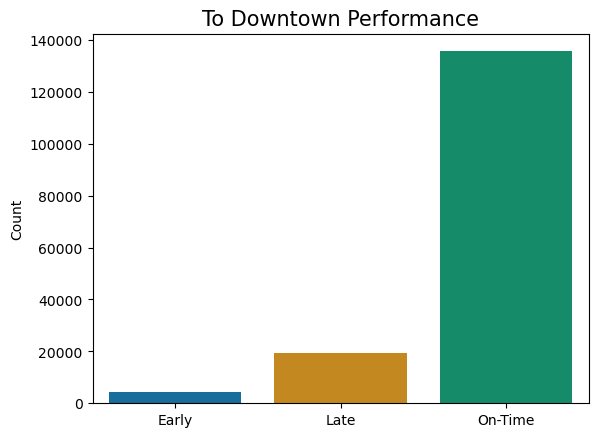

In [14]:
sns.barplot(data = to_downtown_performance.sum(), palette = "colorblind")
plt.title('To Downtown Performance', fontsize = 15)
plt.ylabel('Count');

In [15]:
from_downtown_performance = from_downtown.drop(columns = ['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR', 'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID', 'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE', 'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME', 'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE', 'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'STOP_CANCELLED', 'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES'])
from_downtown_performance.rename(columns={'ADJUSTED_EARLY_COUNT': 'Early', 'ADJUSTED_LATE_COUNT': 'Late', 'ADJUSTED_ONTIME_COUNT': 'On-Time'}, inplace=True)
from_downtown_performance.head(2)

,Early,Late,On-Time
4,0,0,1
5,0,0,1


C:\Users\avame\AppData\Local\Temp\ipykernel_6924\850664367.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = from_downtown_performance.sum(), palette = "colorblind")


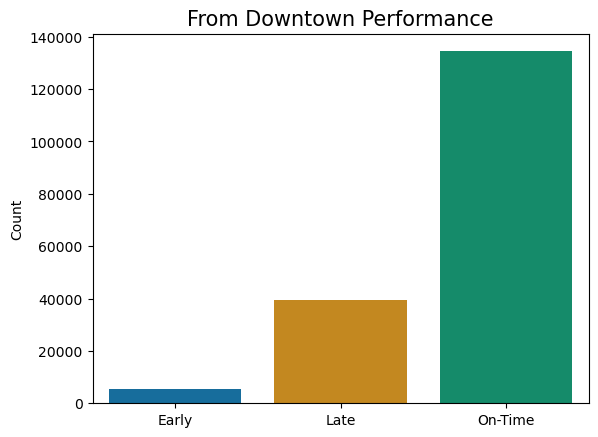

In [16]:
sns.barplot(data = from_downtown_performance.sum(), palette = "colorblind")
plt.title('From Downtown Performance', fontsize = 15)
plt.ylabel('Count');

In [17]:
route_block = wego_clean.drop(columns = ['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID', 'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE', 'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME', 'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE', 'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'STOP_CANCELLED', 'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES'])
route_block

,ROUTE_ABBR,BLOCK_ABBR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,22,2200,0,0,1
1,22,2200,0,0,1
2,22,2200,0,0,1
3,22,2200,0,0,1
4,22,2200,0,0,1
...,...,...,...,...,...
338856,7,702,0,1,0
338857,7,702,0,1,0
338858,7,702,0,0,1
338859,7,702,0,1,0


In [18]:
route_block.rename(columns={'ROUTE_ABBR': 'Route', 'BLOCK_ABBR': 'Block', 'ADJUSTED_EARLY_COUNT': 'Early', 'ADJUSTED_LATE_COUNT': 'Late', 'ADJUSTED_ONTIME_COUNT': 'On-Time'}, inplace=True)
route_block.head(2)

,Route,Block,Early,Late,On-Time
0,22,2200,0,0,1
1,22,2200,0,0,1


In [19]:
#now i'm going to look at route

In [20]:
routes = route_block.drop(columns = ['Block'])
routes.head(2)

,Route,Early,Late,On-Time
0,22,0,0,1
1,22,0,0,1


In [21]:
route_performance = routes.groupby('Route').sum()
route_performance

,Early,Late,On-Time
Route,,,
3,1382,9590,34516
7,433,3417,13417
22,631,2065,22492
23,1286,3230,35137
50,1207,5113,36309
52,1553,10038,37736
55,1531,16748,42080
56,1752,8837,48361


In [22]:
import numpy as np

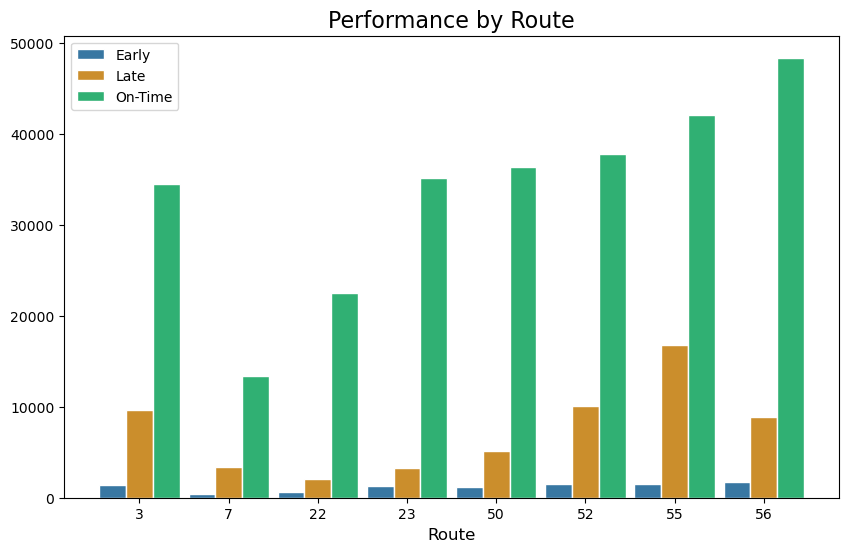

In [23]:
barWidth = 0.3
bars1 = [1382, 433, 631, 1286, 1207, 1553, 1531, 1752]
bars2 = [9590, 3417, 2065, 3230, 5113, 10038, 16748, 8837]
bars3 = [34516, 13417, 22492, 35137, 36309, 37736, 42080, 48361]

r = np.arange(len(bars1))
r2 = r + barWidth
r3 = r2 + barWidth

fig, ax = plt.subplots(figsize = (10,6))
ax.bar(r, bars1, width = barWidth, color =  '#3877a2', edgecolor = 'white', label = 'Early')
ax.bar(r2, bars2, width = barWidth, color = '#cb8e2c', edgecolor = 'white', label = 'Late')
ax.bar(r3, bars3, width = barWidth, color = '#30b073', edgecolor = 'white', label = 'On-Time')

ax.set_xlabel('Route', fontsize = 12)
ax.set_xticks(r + barWidth)
ax.set_xticklabels(['3', '7', '22', '23', '50', '52', '55', '56'])
plt.title('Performance by Route', fontsize = 16)

ax.legend()
plt.show()

In [24]:
#for location, i'm looking at blocks bc i don't want to mess with map coordinates this time

In [25]:
blocks = route_block.drop(columns = ['Route'])
blocks

,Block,Early,Late,On-Time
0,2200,0,0,1
1,2200,0,0,1
2,2200,0,0,1
3,2200,0,0,1
4,2200,0,0,1
...,...,...,...,...
338856,702,0,1,0
338857,702,0,1,0
338858,702,0,0,1
338859,702,0,1,0


In [26]:
block_performance = blocks.groupby('Block').sum()
block_performance

,Early,Late,On-Time
Block,,,
300,308,1936,6330
301,177,907,4681
302,7,138,713
303,69,1580,3423
304,29,214,515
...,...,...,...
8601,10,23,31
8604,2,6,64
9302,1,21,50


In [27]:
#102 blocks is way too many to make another bar plot
#i'm going to make a new column with the percent late for each block

In [28]:
for ind, row in block_performance.iterrows():
    block_performance.loc[ind, 'Percent Late'] = round((block_performance.loc[ind, 'Late'] / (block_performance.loc[ind, 'Early'] + block_performance.loc[ind, 'Late'] + block_performance.loc[ind, 'On-Time'])) * 100,2)

In [29]:
block_performance.head()

,Early,Late,On-Time,Percent Late
Block,,,,
300,308,1936,6330,22.58
301,177,907,4681,15.73
302,7,138,713,16.08
303,69,1580,3423,31.15
304,29,214,515,28.23


In [30]:
#now i can just look for outliers

In [31]:
iqr = block_performance.describe().loc['75%', 'Percent Late'] - block_performance.describe().loc['25%', 'Percent Late']
high = block_performance.describe().loc['75%', 'Percent Late'] + (iqr * 1.5)
high

43.64875

In [32]:
high_late = block_performance.loc[block_performance['Percent Late'] >= high]
high_late

,Early,Late,On-Time,Percent Late
Block,,,,
390,8,83,70,51.55
5509,48,1752,2214,43.65
5513,20,213,239,45.13
5590,0,60,14,81.08
5690,5,34,33,47.22


In [33]:
block_percent = block_performance.drop(columns = ['Early', 'Late', 'On-Time'])
block_percent.head(2)

,Percent Late
Block,
300,22.58
301,15.73


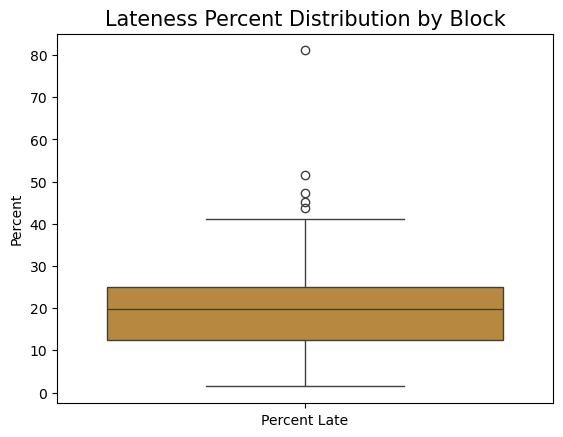

In [34]:
sns.boxplot(data = block_percent, color = '#cb8e2c')
plt.title('Lateness Percent Distribution by Block', fontsize = 15)
plt.ylabel('Percent');

How does time of day or day of week affect on-time performance?

In [36]:
day = wego_clean.drop(columns = ['CALENDAR_ID', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR', 'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID', 'ROUTE_DIRECTION_NAME', 'ROUTE_STOP_SEQUENCE', 'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME', 'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE', 'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'STOP_CANCELLED', 'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES', 'TIME_POINT_ABBR'])
day.head(2)

,SERVICE_ABBR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,1,0,0,1
1,1,0,0,1


In [37]:
#1 = weekday
#2 = saturday
#3 = sunday

In [38]:
#i'm just going to look at day of week bc time of day is a bunch of letters that aren't explained in the data dictionary so i don't know what they mean

In [39]:
#Bre already did day of the week so i guess i'm done